# Sales Performance Analysis & Business Insight - Superstore Dataset

**Project Type:** Data Analyst Portofolio     
**Tools:** Python, Pandas, Matplotlib,Seaborn    
**Dataset:** https://www.kaggle.com/datasets/vivek468/superstore-dataset-final(Sample Superstore)

## Project Objective
Analyzes Superstore sales performance based on retail transactions. This analysis includes sales, profit, discounts, customer segment, region, category, and product performance.

## Business Questions
1. How is the total sales and profit performance?
2. Which year and month had the highest sales?
3. Which regions and customer segments are the most profitable?
4. Which categories and sub-categories give the biggest profits and biggest losses?
5. Does discount have a negative impact on profits?
6. Which products generate high sales but low/negative profits?
7. What business recommendations can be made from the analysis results?

## 1. Import Libary

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')

## 2. Load Dataset

In [11]:
possible_paths = [
    Path('Sample - Superstore.csv'),
    Path('/mnt/data/Sample - Superstore.csv'),
    Path('data/Sample - Superstore.csv')
]
file_path = None
for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError('File Sample - Superstore.csv not found. Place the file in the same folder as the notebook.')

df = pd.read_csv(file_path, encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## 3. Data Understanding

In [16]:
print('Dataset shape:', df.shape)
df.info()

Dataset shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-nu

In [20]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,"9,994.00",9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,"9,994.00",9994,9994,9994,9994,9994,"9,994.00","9,994.00","9,994.00","9,994.00"
unique,NaN,5009,1237,1334,4,793,793,3,1,531,49,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,2001,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,"4,997.50",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"55,190.38",NaN,NaN,NaN,NaN,NaN,229.86,3.79,0.16,28.66
std,"2,885.16",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"32,063.69",NaN,NaN,NaN,NaN,NaN,623.25,2.23,0.21,234.26
min,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,040.00",NaN,NaN,NaN,NaN,NaN,0.44,1.00,0.00,"-6,599.98"
25%,"2,499.25",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"23,223.00",NaN,NaN,NaN,NaN,NaN,17.28,2.00,0.00,1.73
50%,"4,997.50",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"56,430.50",NaN,NaN,NaN,NaN,NaN,54.49,3.00,0.20,8.67
75%,"7,495.75",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"90,008.00",NaN,NaN,NaN,NaN,NaN,209.94,5.00,0.20,29.36


## 4. Data Quality Check

In [25]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [27]:
duplicate_count = df.duplicated().sum()
print('Number of Duplicate Rows:', duplicate_count)

Number of Duplicate Rows: 0


In [38]:
categorical_columns = ['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category']

for col in categorical_columns:
    print(f'{col}:')
    print(df[col].unique())

Ship Mode:
['Second Class' 'Standard Class' 'First Class' 'Same Day']
Segment:
['Consumer' 'Corporate' 'Home Office']
Country:
['United States']
Region:
['South' 'West' 'Central' 'East']
Category:
['Furniture' 'Office Supplies' 'Technology']
Sub-Category:
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


## 5. Data Cleaning & Feature Engineering

In [50]:
# Convert date columns
# Date format in the dataset: month/day/year

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Year Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Profit margin = profit divided by sales
# If sales is 0, the result is set to NaN to avoid division

df['Profit Margin'] = np.where(df['Sales'] != 0, df['Profit']/df['Sales'], np.nan)

# Profit Status
df['Profit Status'] = np.where(df['Profit'] >= 0, 'Profit', 'Loss')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Year Month,Shipping Duration,Profit Margin,Profit Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,November,2016-11,3,0.16,Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,November,2016-11,3,0.30,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,June,2016-06,4,0.47,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,October,2015-10,7,-0.40,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,October,2015-10,7,0.11,Profit


## Exploratory Data Analysis (EDA)

## 6. KPI Summary

In [59]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_discount = df['Discount'].mean()
avg_profit_margin = df['Profit Margin'].mean()
loss_transaction = (df['Profit'] < 0).sum()
loss_rate = loss_transaction / len(df) * 100

kpi_summ = pd.DataFrame({
    'Metric': [
        'Total sales', 'Total Profit', 'Total Orders', 'Total Customer',
        'Average Discount','Average Profit Margin','Loss Transaction','Loss Rate(%)'
    ],
    'Value':[
        total_sales,total_profit,total_orders,total_customers,
        avg_discount,avg_profit_margin,loss_transaction,loss_rate
        
    ]
})

kpi_summ

,Metric,Value
0,Total sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Total Orders,"5,009.00"
3,Total Customer,793.00
4,Average Discount,0.16
5,Average Profit Margin,0.12
6,Loss Transaction,"1,871.00"
7,Loss Rate(%),18.72


## 7. Sales & Profit Trend Analysis

In [64]:
yearyl_performance = df.groupby('Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index().rename(columns={'Order ID' : 'Total Orders'})

yearyl_performance

,Year,Sales,Profit,Total Orders
0,2014,"484,247.50","49,543.97",969
1,2015,"470,532.51","61,618.60",1038
2,2016,"609,205.60","81,795.17",1315
3,2017,"733,215.26","93,439.27",1687


<function matplotlib.pyplot.show(close=None, block=None)>

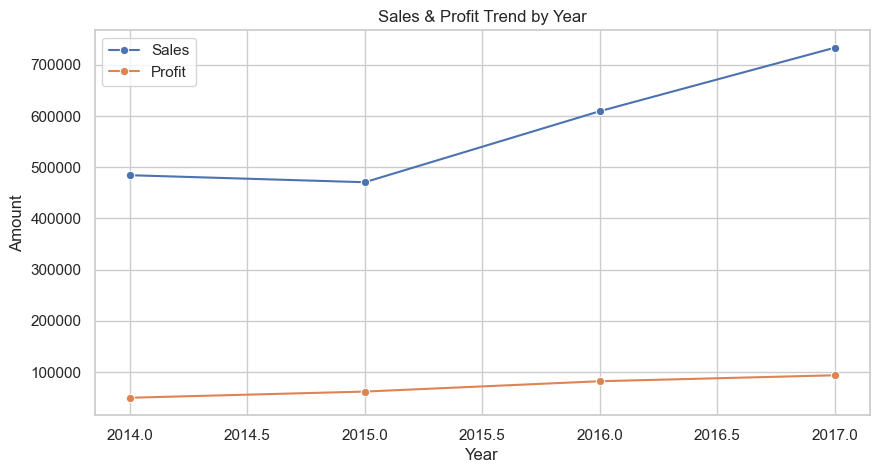

In [70]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearyl_performance, x='Year', y='Sales', marker='o', label='Sales')
sns.lineplot(data=yearyl_performance, x='Year', y='Profit', marker='o',label='Profit')
plt.title('Sales & Profit Trend by Year')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.show

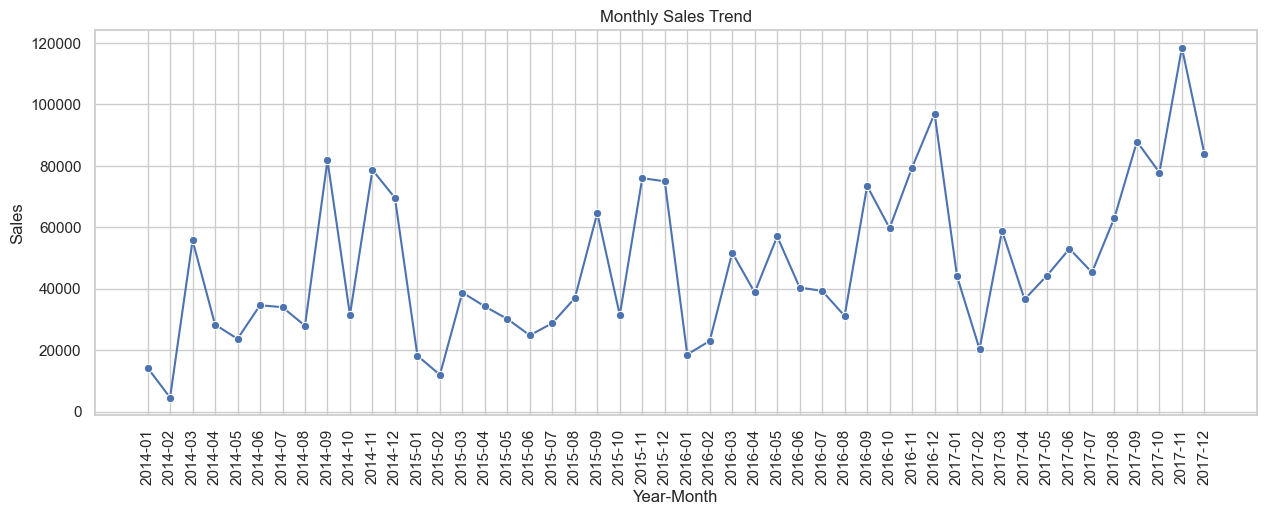

In [84]:
monthly_trend = df.groupby('Year Month').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

plt.figure(figsize=(15,5))
sns.lineplot(data=monthly_trend,x='Year Month', y='Sales', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel('Year-Month')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.show()

## 8. Region & Segment Analysis

In [91]:
region_performance = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index().rename(columns={'Order ID': 'Total Orders'})

region_performance['Profit Margin'] = region_performance['Profit']/region_performance['Sales']
region_performance.sort_values('Profit', ascending=False)

,Region,Sales,Profit,Total Orders,Profit Margin
3,West,"725,457.82","108,418.45",1611,0.15
1,East,"678,781.24","91,522.78",1401,0.13
2,South,"391,721.91","46,749.43",822,0.12
0,Central,"501,239.89","39,706.36",1175,0.08


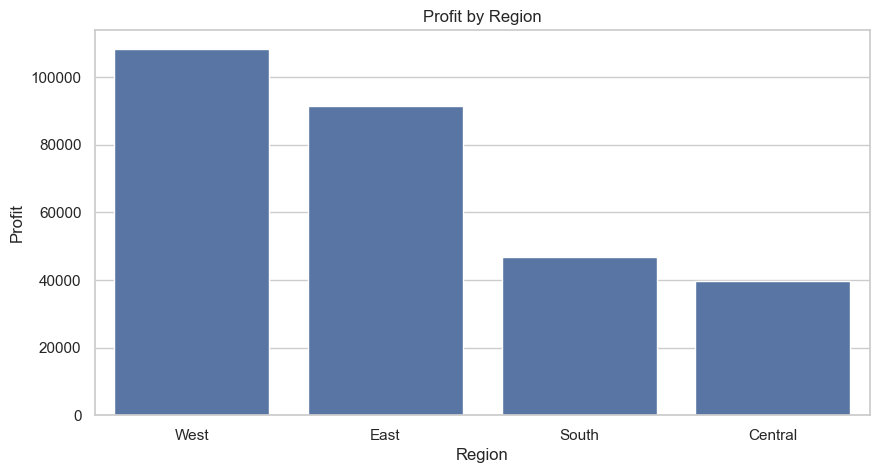

In [95]:
plt.figure(figsize=(10,5))
sns.barplot(data=region_performance.sort_values('Profit', ascending=False), x='Region', y='Profit')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

In [97]:
segment_performance = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique',
    'Customer ID': 'nunique'
}).reset_index().rename(columns={
    'Order ID' : 'Total Orders',
    'Customer ID' : 'Total Customers'
})

segment_performance['Profit Margin'] = segment_performance['Profit'] / segment_performance['Sales']
segment_performance.sort_values('Profit',ascending=False)

,Segment,Sales,Profit,Total Orders,Total Customers,Profit Margin
0,Consumer,"1,161,401.34","134,119.21",2586,409,0.12
1,Corporate,"706,146.37","91,979.13",1514,236,0.13
2,Home Office,"429,653.15","60,298.68",909,148,0.14


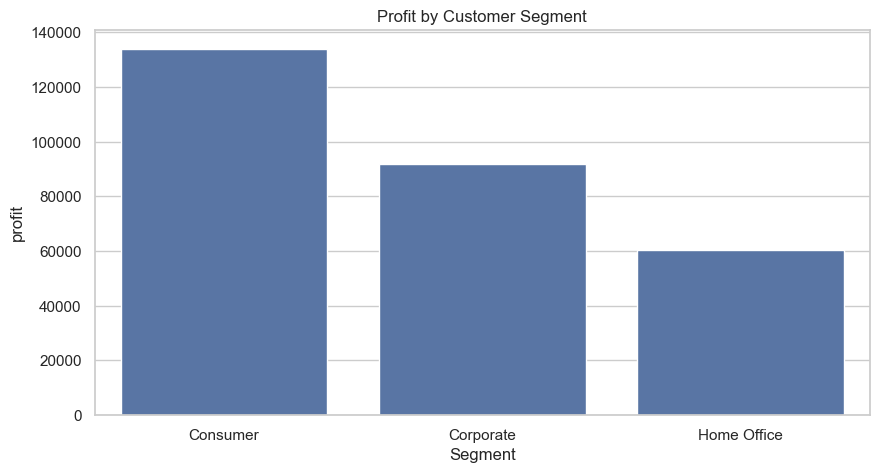

In [101]:
plt.figure(figsize=(10,5))
sns.barplot(data=segment_performance.sort_values('Profit', ascending=False), x='Segment', y='Profit')
plt.title('Profit by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('profit')
plt.show()

## 9. Category & Sub-Category Analysis

In [104]:
category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

category_performance['Profit Margin'] = category_performance['Profit'] / category_performance['Sales']
category_performance.sort_values('Profit', ascending=False)

,Category,Sales,Profit,Quantity,Profit Margin
2,Technology,"836,154.03","145,454.95",6939,0.17
1,Office Supplies,"719,047.03","122,490.80",22906,0.17
0,Furniture,"741,999.80","18,451.27",8028,0.02


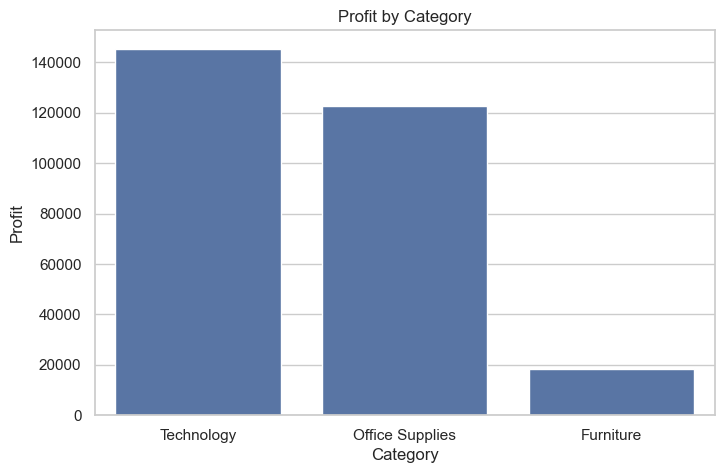

In [106]:
plt.figure(figsize=(8, 5))
sns.barplot(data=category_performance.sort_values('Profit', ascending=False), x='Category', y='Profit')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

In [108]:
sub_category_performance = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()

sub_category_performance['Profit Margin'] = sub_category_performance['Profit'] / sub_category_performance['Sales']
sub_category_performance = sub_category_performance.sort_values('Profit', ascending=False)
sub_category_performance

,Sub-Category,Sales,Profit,Quantity,Discount,Profit Margin
6,Copiers,"149,528.03","55,617.82",234,0.16,0.37
13,Phones,"330,007.05","44,515.73",3289,0.15,0.13
0,Accessories,"167,380.32","41,936.64",2976,0.08,0.25
12,Paper,"78,479.21","34,053.57",5178,0.07,0.43
3,Binders,"203,412.73","30,221.76",5974,0.37,0.15
5,Chairs,"328,449.10","26,590.17",2356,0.17,0.08
14,Storage,"223,843.61","21,278.83",3158,0.07,0.10
1,Appliances,"107,532.16","18,138.01",1729,0.17,0.17
9,Furnishings,"91,705.16","13,059.14",3563,0.14,0.14
7,Envelopes,"16,476.40","6,964.18",906,0.08,0.42


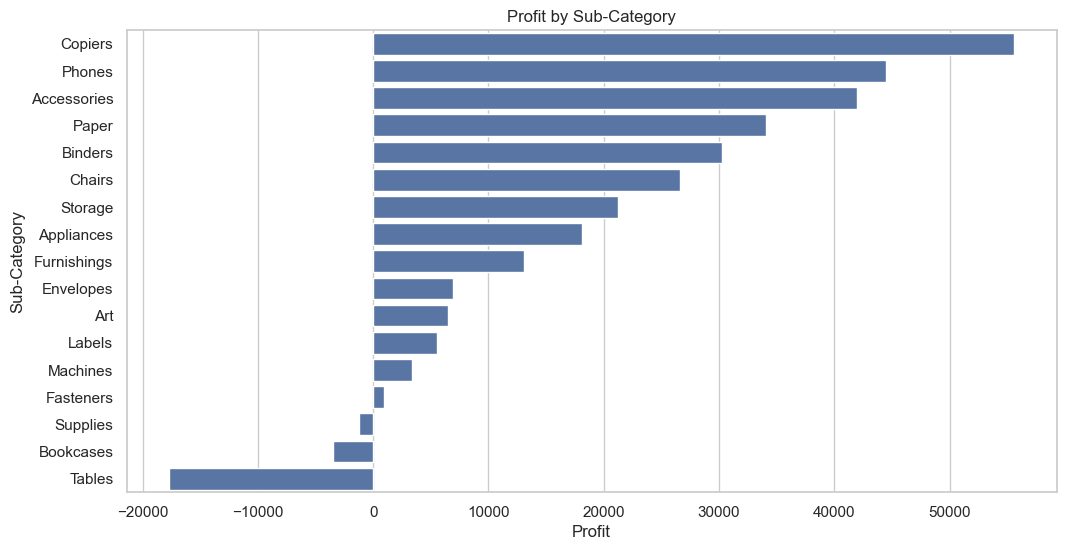

In [110]:
plt.figure(figsize=(12, 6))
sns.barplot(data=sub_category_performance, x='Profit', y='Sub-Category')
plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.show()

## 10. Product Analysis


In [113]:
top_products_sales = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index().sort_values('Sales', ascending=False).head(10)

top_products_sales

,Product Name,Sales,Profit,Quantity,Discount
404,Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20,0.12
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38","7,753.04",31,0.24
444,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08",6,0.50
786,HON 5400 Series Task Chairs for Big and Tall,"21,870.58",0.00,39,0.20
686,GBC DocuBind TL300 Electric Binding System,"19,823.48","2,233.51",37,0.30
688,GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98,48,0.52
805,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38,0.20
787,HP Designjet T520 Inkjet Large Format Printer ...,"18,374.90","4,094.98",12,0.17
683,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27,0.45
813,High Speed Automatic Electric Letter Opener,"17,030.31",-262.00,11,0.07


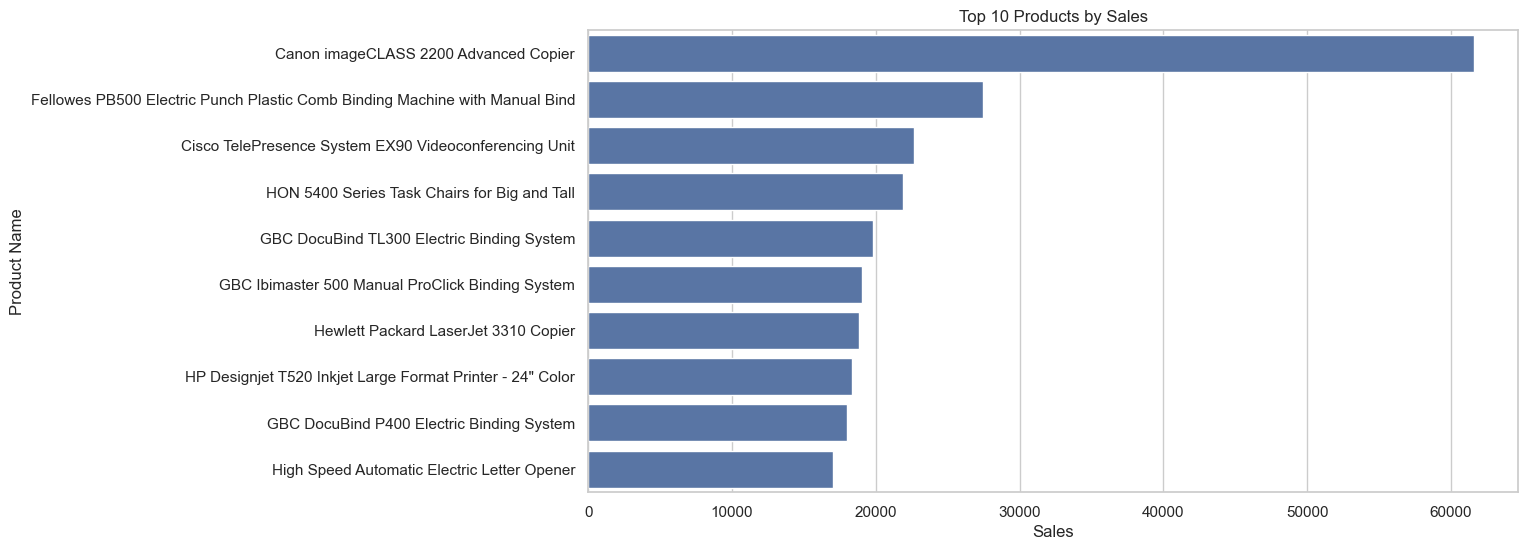

In [115]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_sales, x='Sales', y='Product Name')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.show()

In [117]:
top_products_profit = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index().sort_values('Profit', ascending=False).head(10)

top_products_profit

,Product Name,Sales,Profit,Quantity,Discount
404,Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20,0.12
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38","7,753.04",31,0.24
805,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38,0.20
400,Canon PC1060 Personal Laser Copier,"11,619.83","4,570.93",19,0.15
787,HP Designjet T520 Inkjet Large Format Printer ...,"18,374.90","4,094.98",12,0.17
165,Ativa V4110MDD Micro-Cut Shredder,"7,699.89","3,772.95",11,0.00
19,"3D Systems Cube Printer, 2nd Generation, Magenta","14,299.89","3,717.97",11,0.00
1276,Plantronics Savi W720 Multi-Device Wireless He...,"9,367.29","3,696.28",24,0.06
895,Ibico EPK-21 Electric Binding System,"15,875.92","3,345.28",13,0.33
1840,Zebra ZM400 Thermal Label Printer,"6,965.70","3,343.54",6,0.00


In [119]:
loss_products = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index().sort_values('Profit', ascending=True).head(10)

loss_products

,Product Name,Sales,Profit,Quantity,Discount
475,Cubify CubeX 3D Printer Double Head Print,"11,099.96","-8,879.97",9,0.53
985,Lexmark MX611dhe Monochrome Laser Printer,"16,829.90","-4,589.97",18,0.40
476,Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99",4,0.50
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,"9,917.64","-2,876.12",27,0.28
376,Bush Advantage Collection Racetrack Conference...,"9,544.73","-1,934.40",33,0.35
683,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27,0.45
444,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08",6,0.50
1043,Martin Yale Chadless Opener Electric Letter Op...,"16,656.20","-1,299.18",22,0.10
285,Balt Solid Wood Round Tables,"6,518.75","-1,201.06",19,0.20
364,BoxOffice By Design Rectangular and Half-Moon ...,"1,706.25","-1,148.44",15,0.48


## 11. Discount vs Profit Analysis

In [121]:
discount_analysis = df.groupby('Discount').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).reset_index().rename(columns={'Order ID': 'Transaction Count'})

discount_analysis['Profit Margin'] = discount_analysis['Profit'] / discount_analysis['Sales']
discount_analysis

,Discount,Sales,Profit,Transaction Count,Profit Margin
0,0.00,"1,087,908.47","320,987.60",4798,0.30
1,0.10,"54,369.35","9,029.18",94,0.17
2,0.15,"27,558.52","1,418.99",52,0.05
3,0.20,"764,594.37","90,337.31",3657,0.12
4,0.30,"103,226.65","-10,369.28",227,-0.10
5,0.32,"14,493.46","-2,391.14",27,-0.16
6,0.40,"116,417.78","-23,057.05",206,-0.20
7,0.45,"5,484.97","-2,493.11",11,-0.45
8,0.50,"58,918.54","-20,506.43",66,-0.35
9,0.60,"6,644.70","-5,944.66",138,-0.89


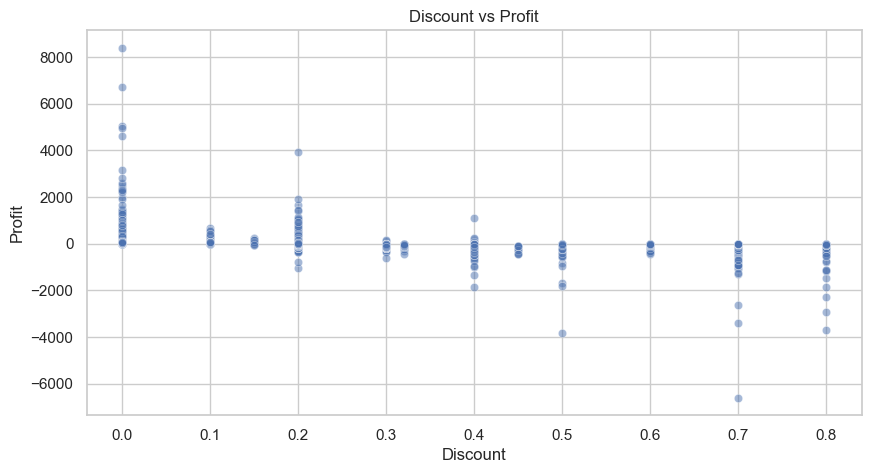

In [124]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

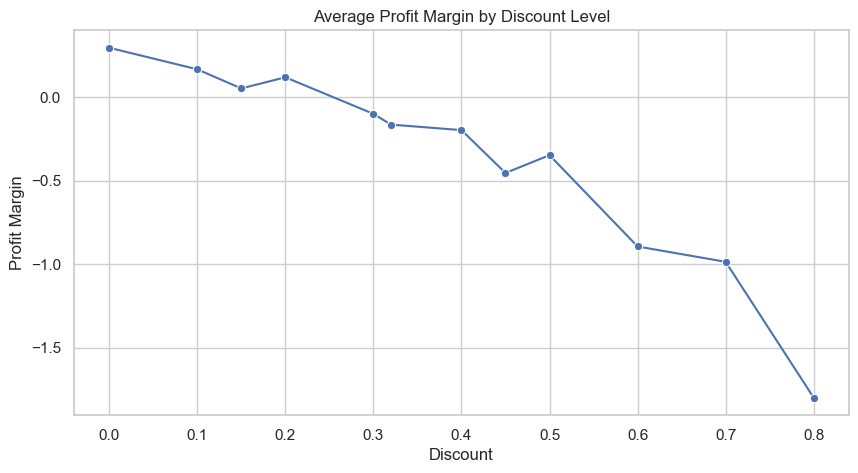

In [126]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=discount_analysis, x='Discount', y='Profit Margin', marker='o')
plt.title('Average Profit Margin by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Profit Margin')
plt.show()

In [132]:
# Korelasi antara discount dan profit
correlation_discount_profit = df[['Discount', 'Profit', 'Sales', 'Quantity']].corr()
correlation_discount_profit

,Discount,Profit,Sales,Quantity
Discount,1.00,-0.22,-0.03,0.01
Profit,-0.22,1.00,0.48,0.07
Sales,-0.03,0.48,1.00,0.20
Quantity,0.01,0.07,0.20,1.00


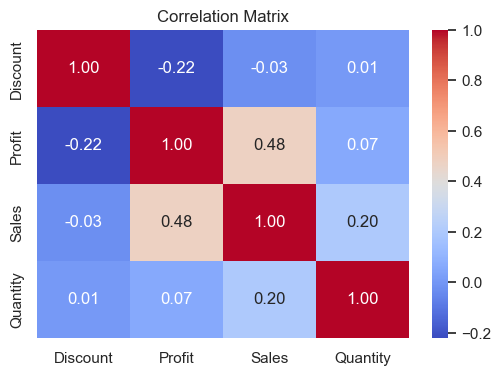

In [134]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_discount_profit, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


## 12. State-Level Profitability

In [137]:
state_performance = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index().rename(columns={'Order ID': 'Total Orders'})

state_performance['Profit Margin'] = state_performance['Profit'] / state_performance['Sales']
state_performance.sort_values('Profit', ascending=False).head(10)

,State,Sales,Profit,Total Orders,Profit Margin
3,California,"457,687.63","76,381.39",1021,0.17
30,New York,"310,876.27","74,038.55",562,0.24
45,Washington,"138,641.27","33,402.65",256,0.24
20,Michigan,"76,269.61","24,463.19",117,0.32
44,Virginia,"70,636.72","18,597.95",115,0.26
12,Indiana,"53,555.36","18,382.94",73,0.34
9,Georgia,"49,095.84","16,250.04",91,0.33
15,Kentucky,"36,591.75","11,199.70",61,0.31
21,Minnesota,"29,863.15","10,823.19",44,0.36
6,Delaware,"27,451.07","9,977.37",44,0.36


In [139]:
state_performance.sort_values('Profit', ascending=True).head(10)

,State,Sales,Profit,Total Orders,Profit Margin
41,Texas,"170,188.05","-25,729.36",487,-0.15
33,Ohio,"78,258.14","-16,971.38",236,-0.22
36,Pennsylvania,"116,511.91","-15,559.96",288,-0.13
11,Illinois,"80,166.10","-12,607.89",276,-0.16
31,North Carolina,"55,603.16","-7,490.91",136,-0.13
4,Colorado,"32,108.12","-6,527.86",79,-0.20
40,Tennessee,"30,661.87","-5,341.69",91,-0.17
1,Arizona,"35,282.00","-3,427.92",108,-0.10
8,Florida,"89,473.71","-3,399.30",200,-0.04
35,Oregon,"17,431.15","-1,190.47",56,-0.07


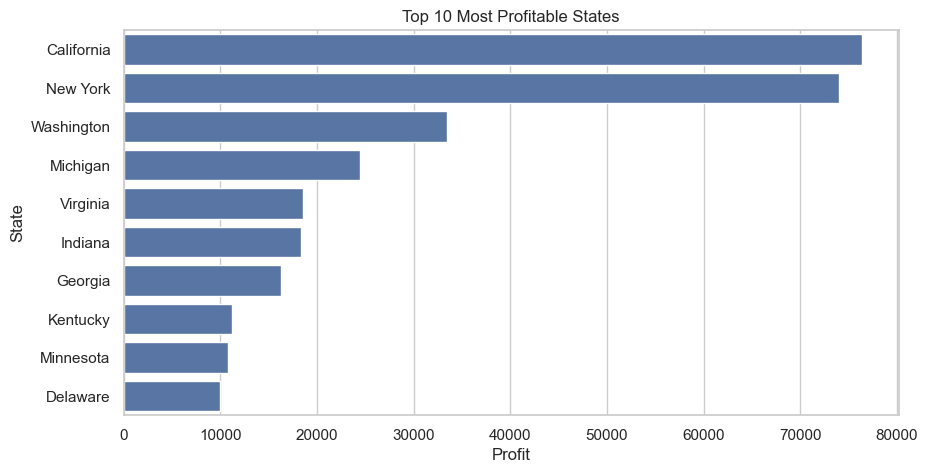

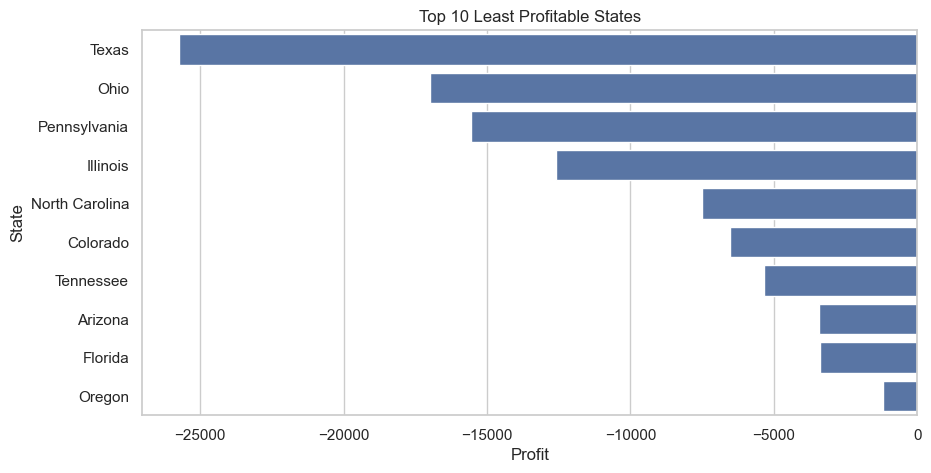

In [141]:
top_states = state_performance.sort_values('Profit', ascending=False).head(10)
loss_states = state_performance.sort_values('Profit', ascending=True).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_states, x='Profit', y='State')
plt.title('Top 10 Most Profitable States')
plt.xlabel('Profit')
plt.ylabel('State')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=loss_states, x='Profit', y='State')
plt.title('Top 10 Least Profitable States')
plt.xlabel('Profit')
plt.ylabel('State')
plt.show()

## 13. Shipping Analysis

In [146]:
shipping_analysis = df.groupby('Ship Mode').agg({
    'Shipping Duration': 'mean',
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index().rename(columns={'Order ID': 'Total Orders'})

shipping_analysis.sort_values('Shipping Duration')

,Ship Mode,Shipping Duration,Sales,Profit,Total Orders
1,Same Day,0.04,"128,363.12","15,891.76",264
0,First Class,2.18,"351,428.42","48,969.84",787
2,Second Class,3.24,"459,193.57","57,446.64",964
3,Standard Class,5.01,"1,358,215.74","164,088.79",2994


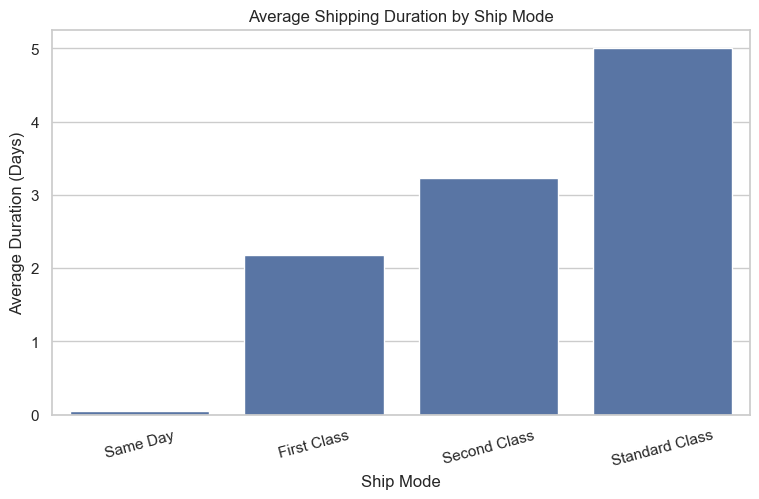

In [148]:
plt.figure(figsize=(9, 5))
sns.barplot(data=shipping_analysis.sort_values('Shipping Duration'), x='Ship Mode', y='Shipping Duration')
plt.title('Average Shipping Duration by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Average Duration (Days)')
plt.xticks(rotation=15)
plt.show()

## 14. Customer Analysis

In [151]:
customer_performance = df.groupby(['Customer ID', 'Customer Name']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index().rename(columns={'Order ID': 'Total Orders'})

customer_performance['Profit Margin'] = customer_performance['Profit'] / customer_performance['Sales']
customer_performance.sort_values('Sales', ascending=False).head(10)

,Customer ID,Customer Name,Sales,Profit,Total Orders,Profit Margin
700,SM-20320,Sean Miller,"25,043.05","-1,980.74",5,-0.08
741,TC-20980,Tamara Chand,"19,052.22","8,981.32",5,0.47
621,RB-19360,Raymond Buch,"15,117.34","6,976.10",6,0.46
730,TA-21385,Tom Ashbrook,"14,595.62","4,703.79",4,0.32
6,AB-10105,Adrian Barton,"14,473.57","5,444.81",10,0.38
434,KL-16645,Ken Lonsdale,"14,175.23",806.86,12,0.06
669,SC-20095,Sanjit Chand,"14,142.33","5,757.41",9,0.41
327,HL-15040,Hunter Lopez,"12,873.30","5,622.43",6,0.44
683,SE-20110,Sanjit Engle,"12,209.44","2,650.68",11,0.22
131,CC-12370,Christopher Conant,"12,129.07","2,177.05",5,0.18


In [153]:
customer_performance.sort_values('Profit', ascending=False).head(10)

,Customer ID,Customer Name,Sales,Profit,Total Orders,Profit Margin
741,TC-20980,Tamara Chand,"19,052.22","8,981.32",5,0.47
621,RB-19360,Raymond Buch,"15,117.34","6,976.10",6,0.46
669,SC-20095,Sanjit Chand,"14,142.33","5,757.41",9,0.41
327,HL-15040,Hunter Lopez,"12,873.30","5,622.43",6,0.44
6,AB-10105,Adrian Barton,"14,473.57","5,444.81",10,0.38
730,TA-21385,Tom Ashbrook,"14,595.62","4,703.79",4,0.32
160,CM-12385,Christopher Martinez,"8,954.02","3,899.89",4,0.44
424,KD-16495,Keith Dawkins,"8,181.26","3,038.63",12,0.37
48,AR-10540,Andy Reiter,"6,608.45","2,884.62",6,0.44
234,DR-12940,Daniel Raglin,"8,350.87","2,869.08",8,0.34


In [155]:
customer_performance.sort_values('Profit', ascending=True).head(10)

,Customer ID,Customer Name,Sales,Profit,Total Orders,Profit Margin
180,CS-12505,Cindy Stewart,"5,690.05","-6,626.39",6,-1.16
310,GT-14635,Grant Thornton,"9,351.21","-4,108.66",3,-0.44
459,LF-17185,Luke Foster,"3,930.51","-3,583.98",7,-0.91
711,SR-20425,Sharelle Roach,"3,233.48","-3,333.91",5,-1.03
322,HG-14965,Henry Goldwyn,"3,247.64","-2,797.96",12,-0.86
555,NC-18415,Nathan Cano,"2,218.99","-2,204.81",6,-0.99
666,SB-20290,Sean Braxton,"8,057.89","-2,082.75",7,-0.26
700,SM-20320,Sean Miller,"25,043.05","-1,980.74",5,-0.08
165,CP-12340,Christine Phan,"5,888.27","-1,850.30",8,-0.31
560,NF-18385,Natalie Fritzler,"8,322.83","-1,695.97",7,-0.20


## 15. Export Cleaned Dataset

In [162]:
df.to_csv(
    "superstore_cleaned.csv",
    index=False,
    sep=','
)